In [1]:
import pydicom
import nibabel as nib
import SimpleITK as sitk
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from pydicom import dcmread
from pydicom.errors import InvalidDicomError
from collections import defaultdict
from pydicom.data import get_testdata_files

plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 用黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号
# print(pydicom.__version__)
# print(sitk.__version__)

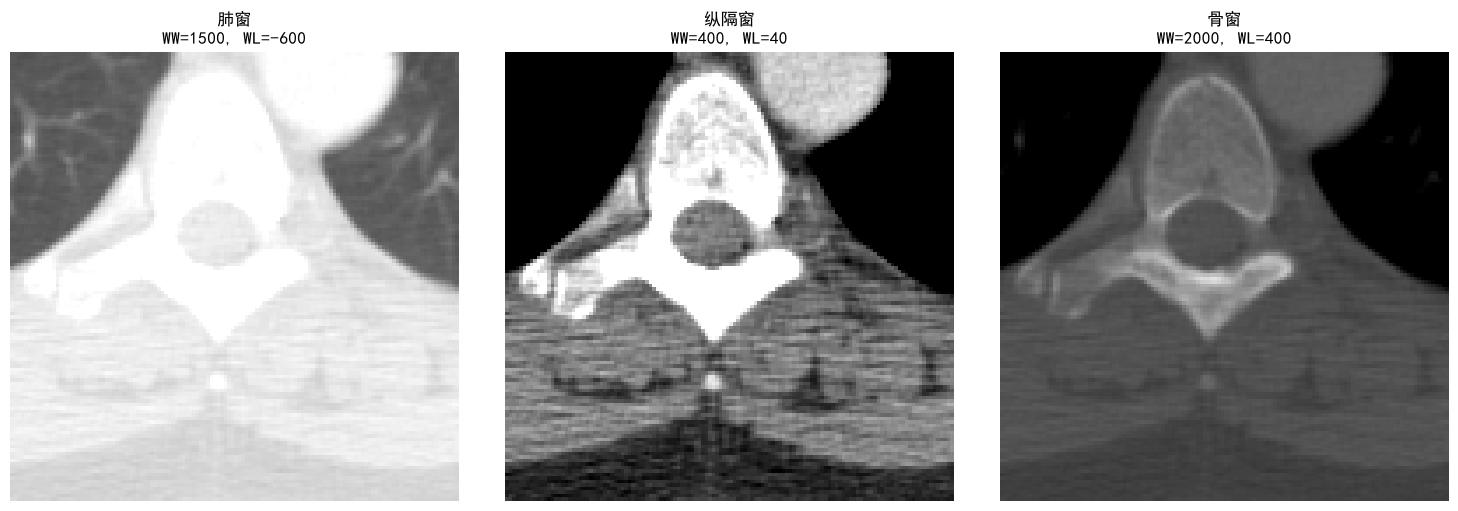

In [2]:
path = get_testdata_files("CT_small.dcm")
ds = pydicom.dcmread(path[0])
# print(ds)
pixel = ds.pixel_array
hu = pixel.astype(np.float32) * float(ds.RescaleSlope) + float(ds.RescaleIntercept)
# print(hu)
# print(f"HU range: {hu.min():.0f} to {hu.max():.0f}")
def apply_window(hu, window_center, window_width):
    """把 HU 值按窗宽窗位映射到 0~1，用于显示。"""
    low = window_center - window_width/2
    high = window_center + window_width/2
    return np.clip((hu - low) / (high - low), 0, 1)

WINDOWS = {
    "肺窗":   (-600, 1500),   # 看肺，能看清肺纹理和结节
    "纵隔窗": (40, 400),      # 看软组织、心脏、血管
    "骨窗":   (400, 2000),    # 看骨头，能看清骨皮质和骨小梁
}
names = ["肺窗", "纵隔窗", "骨窗"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, name in zip(axes, names):
    wc, ww = WINDOWS[name]
    img = apply_window(hu, wc, ww)
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{name}\nWW={ww}, WL={wc}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [3]:
def load_series(series_dir):
    """读取文件夹里的一个 CT 序列，按空间位置排序后返回三维 HU 数组、层间距和首层元数据。"""
    # 第一步：按 SeriesInstanceUID 分组
    # 【要点】一个文件夹 ≠ 一个序列：同一病人的多次扫描、不同模态常混在一个目录里。
    # 反例是 pydicom 自带测试目录 —— 78 个 .dcm 分成 22 组、跨 8 种模态，CT 全是一张一张的。
    groups = defaultdict(list)
    for file in Path(series_dir).glob("*.dcm"):
        try:
            # 【要点】stop_before_pixels=True 只读元数据；分组用不到像素，能省掉大量 IO
            ds = dcmread(file, stop_before_pixels=True)
        except InvalidDicomError:
            continue                                      # 文件头坏了，读不了
        # 【要点】DICOM 字段是"可选"的，缺失时属性访问抛 AttributeError 而不是返回 None，
        # 必须用 getattr / .get() 兜底（本 notebook 在 Modality 上就踩过一次）
        uid = getattr(ds, "SeriesInstanceUID", None)
        if uid is None:
            continue                                      # 不是图像序列
        groups[uid].append(file)                          # 存【路径】，不是 ds

    if not groups:
        raise ValueError(f"{series_dir} 里没有找到可用的 DICOM 序列")

    series_uid, files = max(groups.items(), key=lambda item: len(item[1]))  # 取文件数最多的序列
    print(f"共 {len(groups)} 个序列，取文件数最多的：{len(files)} 层")

    # 第二步：按解剖位置排序
    # 【要点】文件名顺序和 InstanceNumber 都不保证等于空间顺序，
    # 只有 ImagePositionPatient[2]（真实空间 z 坐标）能用来排序
    slices = [dcmread(file) for file in files]
    slices.sort(key=lambda ds: ds.ImagePositionPatient[2])

    # 第三步：计算真实的层间距
    # 【要点】标称层厚 SliceThickness ≠ 实际层间距：本例声明 1.25 mm，
    # 相邻层 z 差值平均却是 6.25 mm（差 5 倍），照 SliceThickness 建三维几何会全错
    z_positions = [s.ImagePositionPatient[2] for s in slices]
    if len(slices) > 1:
        spacing_z = float(np.mean(np.diff(z_positions)))  # 取平均，避免个别切片 z 坐标异常
    else:
        spacing_z = float("nan")   # 【要点】单层时 np.diff 为空，np.mean 会返回 NaN 并给警告
    print(f"标称层厚 {slices[0].SliceThickness}，实际层间距 {spacing_z:.3f} mm")

    # 第四步：换算 HU 后堆成三维数组
    # 【要点】HU = 像素值 × RescaleSlope + RescaleIntercept，这一步不能省：
    # CT 的 HU 是绝对刻度（水=0、空气≈-1000），不是普通图像那种 0~255 相对亮度
    volume = np.stack([
        s.pixel_array.astype(np.float32) * float(s.RescaleSlope) + float(s.RescaleIntercept)
        for s in slices
    ])
    print(f"三维数组形状: {volume.shape}")   # (层数, 高, 宽)
    return volume, spacing_z, slices[0]


# 数据放在 pytorch/data/dicom/CT-chest：44 层胸部 CT，来自 HuggingFace 的
# ndonyapour/dicom-sample-files（完整下载地址记在 docs 的交付文档里）
# 【要点】选公开数据集要先确认它存的是原始 DICOM 还是预处理产物 ——
# HuggingFace 上的 LIDC-IDRI 镜像几乎全是 .npy/.npz，练不了 DICOM 读取
SERIES_DIR = Path(r"E:\code\PycharmProjects\pythonProject\pytorch\data\dicom\CT-chest")
volume, spacing_z, first_slice = load_series(SERIES_DIR)

共 1 个序列，取文件数最多的：44 层
标称层厚 1.250000，实际层间距 6.250 mm
三维数组形状: (44, 512, 512)


In [4]:
# ============ 探一探：这个文件夹里到底有哪些序列 ============
# SERIES_DIR 在 cell 3 里定义。换别的数据目录时只改那一处。
# 【要点】换新数据先跑这段，统计每个序列的层数和模态 —— 一眼就能判断数据对不对。
# 本例只有一行「层数=44 模态={'CT'}」；若打出好几行不同模态，说明目录里混着多个序列。
counts = defaultdict(list)
for f in sorted(SERIES_DIR.glob("*.dcm")):
    try:
        ds = dcmread(f, stop_before_pixels=True)
    except InvalidDicomError:
        continue                                     # 文件头损坏的样本，跳过
    uid = getattr(ds, "SeriesInstanceUID", None)
    if uid is not None:
        # 用 .get() 而不是 .Modality：字段缺失时 pydicom 属性访问会抛 AttributeError
        counts[uid].append(ds.get("Modality", "无"))

print(f"{SERIES_DIR} 里可用的序列：")
for uid, mods in sorted(counts.items(), key=lambda kv: -len(kv[1])):
    print(f"  层数={len(mods):3d}  模态={set(mods)}  UID={uid}")

E:\code\PycharmProjects\pythonProject\pytorch\data\dicom\CT-chest 里可用的序列：
  层数= 44  模态={'CT'}  UID=1.2.840.113619.2.428.3.163579080.618.1743654594.50


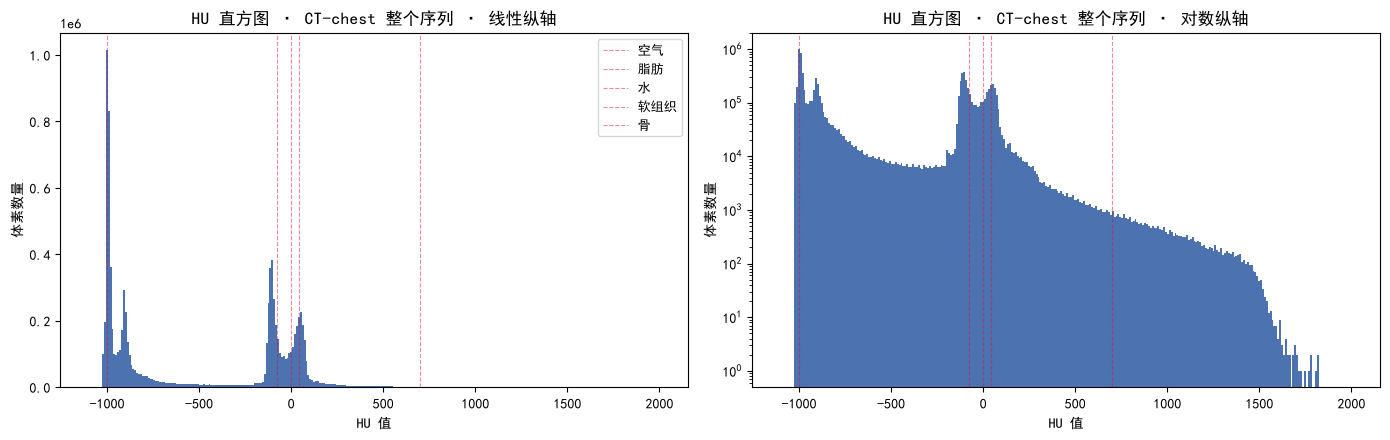

In [7]:
# ============ HU 直方图 ============
def plot_hu_histogram(hu_flat, title="HU 直方图"):
    """画 HU 直方图：左图线性纵轴、右图对数纵轴。输入是展平成一维的 HU 数组。"""
    # 【要点】CT 的 HU 是绝对刻度，所以峰的横轴位置本身带物理含义，直方图可以直接
    # 当"体检报告"：空气峰没落在 -1000 附近，就说明 HU 换算（Slope/Intercept）有问题
    REF_HU = {"空气": -1000, "脂肪": -80, "水": 0, "软组织": 40, "骨": 700}

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
    for ax, (label, use_log) in zip(axes, [("线性纵轴", False), ("对数纵轴", True)]):
        # range 手动固定：HU 理论上能到 +3000，但极端值的体素极少，
        # 让 matplotlib 自动定范围会把 x 轴拉到几千，主峰全挤成左边一小条
        ax.hist(hu_flat, bins=300, range=(-1100, 2000), color="#4C72B0")
        for name, hu_ref in REF_HU.items():
            ax.axvline(hu_ref, color="crimson", ls="--", lw=0.8, alpha=0.5, label=name)
        if use_log:
            # 【要点】必须配一张对数纵轴：空气/骨的体素数比软组织少几个数量级，
            # 线性纵轴下它们会被压成贴着地面看不见的一条线
            ax.set_yscale("log")
        ax.set_xlabel("HU 值")
        ax.set_ylabel("体素数量")
        ax.set_title(f"{title} · {label}")
    axes[0].legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.savefig("outputs/01_hu_histogram.png", dpi=200, bbox_inches="tight")
    plt.show()


# 【要点】统计整卷而不是单张：单张直方图受这一层切到什么解剖结构影响极大
# （切到肺和切到肝完全是两张图），整卷才反映病人整体的组织成分
# .ravel() 把 (44, 512, 512) 展平成一维：直方图只统计"每个 HU 值出现多少次"，
# 不关心体素在哪个位置
plot_hu_histogram(volume.ravel(), "HU 直方图 · CT-chest 整个序列")
pixel_spacing = [float(v) for v in first_slice.PixelSpacing]   # [y, x]，单位 mm

In [8]:
def resample_to_spacing(image, new_spacing=(1.0, 1.0, 1.0)):
    """把图像重采样到统一的体素间距，返回新的图像对象。"""
    old_size = image.GetSize()  # 顺序是 (x, y, z)
    old_spacing = image.GetSpacing()  # 顺序是 (x, y, z)
     # 总物理长度不变，间距变小则体素数变多
    new_size = [int(round(o * s / n)) for o, s, n in zip(old_size, old_spacing, new_spacing)]
    return sitk.Resample(
        image, new_size, sitk.Transform(), sitk.sitkLinear,
        image.GetOrigin(), new_spacing, image.GetDirection(), -1000, image.GetPixelID()
    )
# 把 numpy 数组交给 SimpleITK 时要指定间距和原点，否则它会当成 1mm 处理
sitk_image = sitk.GetImageFromArray(volume)
sitk_image.SetSpacing((float(pixel_spacing[1]), float(pixel_spacing[0]), spacing_z))  # (x, y, z)
resampled = resample_to_spacing(sitk_image, new_spacing=(1.0, 1.0, 1.0))
print("重采样前:", sitk_image.GetSize(), sitk_image.GetSpacing())
print("重采样后:", resampled.GetSize(), resampled.GetSpacing())
volume_new = sitk.GetArrayFromImage(resampled)   # 拿回 numpy 时顺序又变回 (z, y, x)

重采样前: (512, 512, 44) (0.855469, 0.855469, 6.25)
重采样后: (438, 438, 275) (1.0, 1.0, 1.0)


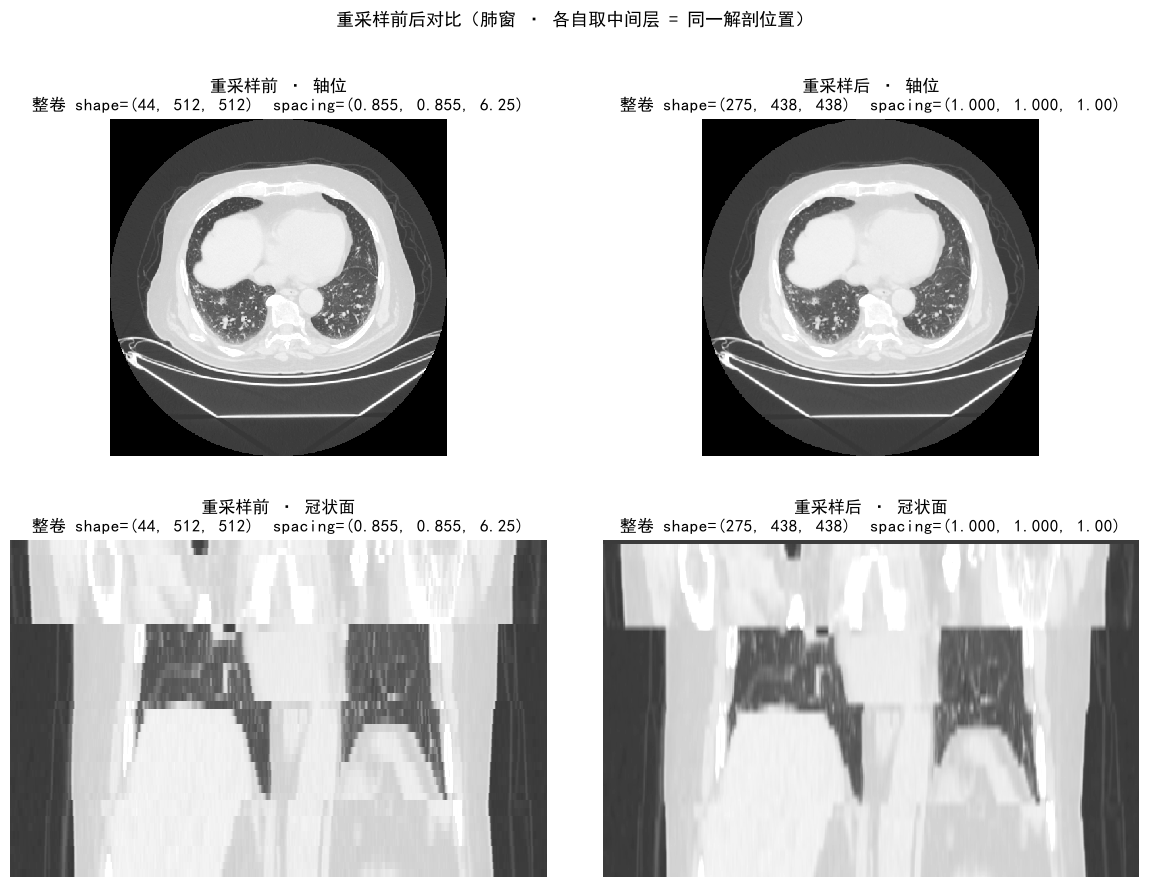

In [9]:
# ============ 重采样前后对比 ============
# 【要点】重采样后体素数变了（层数 44→275、层内 512→438），所以不能拿同一个下标当"同一层"：
# index=22 在两卷里对应的物理 z 差了 5 倍多（0.855mm vs 6.25mm 的间距）。
# 好在重采样保住了 origin 和 direction，物理坐标是连续的，
# 因此取各自的中间层（index = n // 2）就落在同一个解剖位置上，最多差半层。
WC, WW = WINDOWS["肺窗"]                      # 复用前面定义好的肺窗，不另起一套窗宽窗位
spacing_before = sitk_image.GetSpacing()      # (x, y, z)
spacing_after = resampled.GetSpacing()

# 每一行是一组对比：左=重采样前，右=重采样后。元组依次是
# (面名称, 重采样前的切片, 重采样后的切片, 前的纵横比, 后的纵横比, origin)
# 【要点】aspect = 竖直方向间距 / 水平方向间距。按它显示才能还原真实物理形状：
# 重采样前后覆盖的物理视野一样大（约 438mm × 275mm），显示出来就该一样大；
# 如果都用 aspect="auto" 各自填满子图，"重采样前 z 方向被拉长、分辨率低"这件事就看不出来了
AXIAL_ASPECT_BEFORE = spacing_before[1] / spacing_before[0]   # 轴位：竖直=y，水平=x
CORONAL_ASPECT_BEFORE = spacing_before[2] / spacing_before[0]  # 冠状面：竖直=z，水平=x
panels = [
    ("轴位", volume[volume.shape[0] // 2], volume_new[volume_new.shape[0] // 2],
     AXIAL_ASPECT_BEFORE, spacing_after[1] / spacing_after[0], "upper"),
    ("冠状面", volume[:, volume.shape[1] // 2, :], volume_new[:, volume_new.shape[1] // 2, :],
     CORONAL_ASPECT_BEFORE, spacing_after[2] / spacing_after[0], "lower"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for row, (plane, before_slice, after_slice, aspect_before, aspect_after, origin) in enumerate(panels):
    for col, (img, whole_shape, spacing, aspect, label) in enumerate([
        (before_slice, volume.shape, spacing_before, aspect_before, "重采样前"),
        (after_slice, volume_new.shape, spacing_after, aspect_after, "重采样后"),
    ]):
        ax = axes[row, col]
        # apply_window 把 HU 压到 0~1，配 vmin/vmax=0/1 就是标准灰度显示；
        # interpolation="nearest" 是为了让放大后的体素保持方块状 —— 看的正是"一格多大"
        # 冠状面用 origin="lower"：z 增大方向朝上，符合解剖习惯
        ax.imshow(apply_window(img, WC, WW), cmap="gray", vmin=0, vmax=1,
                  aspect=aspect, origin=origin, interpolation="nearest")
        ax.set_title(f"{label} · {plane}\n整卷 shape={whole_shape}  "
                     f"spacing=({spacing[0]:.3f}, {spacing[1]:.3f}, {spacing[2]:.2f})")
        ax.axis("off")

plt.suptitle("重采样前后对比（肺窗 · 各自取中间层 = 同一解剖位置）", fontsize=13)
# 图像按 aspect 显示后会被压扁/留白，tight_layout 算不准间距，补一个 hspace 避免标题贴到上图
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.subplots_adjust(hspace=0.25)
plt.savefig("outputs/04_resample_compare.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
# ============ 把 DICOM 序列写成 NIfTI ============
# 【要点】真实流程里这一步一般交给 dcm2niix 这类工具，NIfTI 才是下游（训练、配准）
# 真正读的格式。这里用 SimpleITK 写、用 nibabel 读，练的是"读"而不是"写"。
# 特意写【没重采样】的 sitk_image：层数 44 和 volume 一一对应，后面比较最干净
NII_PATH = SERIES_DIR.parent / "CT-chest.nii.gz"   # 落在 pytorch/data/dicom/ 下，和序列文件夹同级
sitk.WriteImage(sitk_image, str(NII_PATH))
print(f"已写出 {NII_PATH}，{NII_PATH.stat().st_size / 1024 / 1024:.1f} MB")

已写出 E:\code\PycharmProjects\pythonProject\pytorch\data\dicom\CT-chest.nii.gz，11.8 MB


对齐后 shape: (44, 512, 512)  dtype: float32
整卷逐体素比较: True  最大绝对差 = 0.0


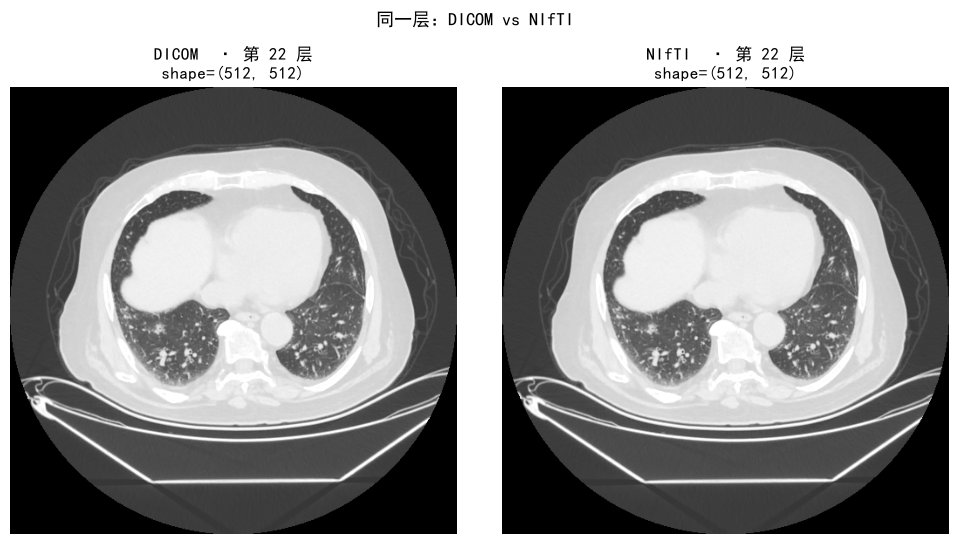

In [18]:
# ============ 用 nibabel 读 NIfTI，确认和 DICOM 是同一份数据 ============
nii = nib.load(NII_PATH)
# 【要点】nib.load 是惰性的：nii.dataobj 只是内存映射，get_fdata() 才真正把体素读进内存
# 【要点】两边轴序完全【逆序】：nibabel 是 (x, y, z)，我们的 volume 是 (z, y, x)。
# 整体翻过来（transpose 返回的是视图，不复制数据），后面就不用到处写 .T 了。
# 显式写 dtype=np.float32：get_fdata() 默认返回 float64，会白白多占一倍内存
nii_zyx = np.transpose(nii.get_fdata(dtype=np.float32), (2, 1, 0))
print("对齐后 shape:", nii_zyx.shape, " dtype:", nii_zyx.dtype)

# 【要点】"是不是同一个东西"不能只靠肉眼看图 —— 直接逐体素比，这才是硬证据
print("整卷逐体素比较:", np.allclose(nii_zyx, volume),
      " 最大绝对差 =", float(np.abs(nii_zyx - volume).max()))

# ---------- 同一层并排对比 ----------
SLICE = volume.shape[0] // 2        # 第 22 层（中间层），两边是同一个解剖位置
WC, WW = WINDOWS["肺窗"]            # 复用前面定义好的肺窗

dicom_slice = volume[SLICE]
nifti_slice = nii_zyx[SLICE]
diff = np.abs(nifti_slice - dicom_slice)

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))
for ax, img, title in [
    (axes[0], dicom_slice, f"DICOM  · 第 {SLICE} 层"),
    (axes[1], nifti_slice, f"NIfTI  · 第 {SLICE} 层"),
]:
    ax.imshow(apply_window(img, WC, WW), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{title}\nshape={img.shape}")
    ax.axis("off")


plt.suptitle("同一层：DICOM vs NIfTI ", fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.savefig("outputs/05_dicom_vs_nifti.png", dpi=200, bbox_inches="tight")
plt.show()